# Expected WAR (xWAR) — Starting Pitchers, v2
### Runs-per-9 (RA9) approach, calibrated empirically against actual WAR

**Pipeline:** this mirrors the position-player xWAR pipeline's structure (predict a rate
stat from skill inputs, convert to a counting stat, then convert to wins via empirically-calibrated
constants) but the pitcher version is built around **runs allowed per 9 innings (RA9)** instead of
wOBA/BsR.

1. Predict **xRA9** (expected earned runs allowed per 9 innings) from skill inputs — BB%, K%, batted-ball
   shape, and contact quality allowed — using Linear Regression, Random Forest, and XGBoost.
2. Scale xRA9 by playing time: `xRA = xRA9 * (IP / 9)` — expected total earned runs allowed.
3. Convert runs to wins **the same closed-form way as the position-player model** — solve for a
   replacement-level RA9 and a runs-per-win constant that jointly minimize error against actual WAR,
   instead of guessing standard constants.

**Scope note:** this dataset is starters only (100+ IP/season), so there is no starter/reliever split
needed here — that would matter for a future reliever-specific dataset, not this one.

**Known limitation:** the target used to train the RA9 models is **ERA** (earned runs per 9), not true
total runs allowed per 9 — the dataset doesn't include unearned runs. ERA is the closest available
proxy for "actual runs prevented" and is standard practice (it's what FIP/xFIP/SIERA are themselves
validated against), but it means defense-independent unearned runs are not captured in the target.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Step 1 — Load and clean

- Convert percent-string columns to floats
- Drop the duplicate `HR/FB.1` column (identical to `HR/FB`)
- No player-season deduplication needed here — unlike the position-player dataset, this FanGraphs
  starters export is already one row per player-season (trades are pre-aggregated server-side, not
  split into multiple rows)

In [2]:
df = pd.read_csv('expectedwarpitchers.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (590, 43)


,#,Season,Name,Team,IP,BABIP,GB%,HR/FB,ERA,FIP,...,H-Contact%,H-Zone%,C-Contact%,C-Zone%,S-Contact%,S-Zone%,W-Contact%,W-Zone%,K%,BB%
0,508,2022,Spencer Strider,ATL,107.1000,0.2900,42.00%,8.50%,2.7700,1.9200,...,83.20%,28.00%,35.20%,22.20%,66.70%,41.50%,0.00%,8.30%,38.10%,7.90%
1,509,2023,Spencer Strider,ATL,186.2000,0.3160,34.10%,12.20%,3.8600,2.8500,...,81.70%,27.30%,26.80%,21.60%,62.30%,42.70%,2.90%,8.40%,36.80%,7.60%
2,119,2021,Corbin Burnes,MIL,167.0000,0.3090,48.80%,6.10%,2.4300,1.6300,...,85.80%,23.90%,28.80%,25.00%,67.60%,42.10%,6.90%,9.00%,35.60%,5.20%
3,177,2024,Garrett Crochet,CHW,146.0000,0.3180,45.10%,14.40%,3.5800,2.6900,...,81.40%,29.70%,43.80%,18.90%,65.10%,44.20%,22.20%,7.20%,35.10%,5.50%
4,48,2024,Blake Snell,SFG,104.0000,0.2660,42.00%,6.50%,3.1200,2.4300,...,79.60%,21.70%,31.50%,24.50%,66.60%,43.40%,0.00%,10.40%,34.70%,10.50%


In [3]:
# --- Convert percent-string columns ('23.4%' -> 0.234) ---
pct_cols = [
    'GB%', 'HR/FB', 'LD%', 'FB%', 'IFFB%', 'HR/FB.1',
    'O-Swing%', 'Z-Swing%', 'Swing%', 'O-Contact%', 'Z-Contact%', 'Contact%', 'SwStr%',
    'Soft%', 'Med%', 'Hard%', 'Barrel%', 'HardHit%', 'CStr%', 'CSW%',
    'H-Contact%', 'H-Zone%', 'C-Contact%', 'C-Zone%', 'S-Contact%', 'S-Zone%',
    'W-Contact%', 'W-Zone%', 'K%', 'BB%',
]
for col in pct_cols:
    df[col] = df[col].astype(str).str.rstrip('%').astype(float) / 100

# HR/FB and HR/FB.1 are exact duplicates -- drop one
df = df.drop(columns=['HR/FB.1'])

# Tidy column names for the features we'll actually use
df = df.rename(columns={
    'K%': 'k_pct', 'BB%': 'bb_pct', 'HR/FB': 'hr_fb_pct',
    'GB%': 'gb_pct', 'FB%': 'fb_pct', 'LD%': 'ld_pct', 'IFFB%': 'iffb_pct',
    'Barrel%': 'barrel_pct', 'HardHit%': 'hardhit_pct',
    'Soft%': 'soft_pct', 'Med%': 'med_pct', 'Hard%': 'hard_pct',
    'SwStr%': 'swstr_pct', 'CSW%': 'csw_pct',
    'EV': 'ev', 'IP': 'ip', 'ERA': 'era', 'WAR': 'war',
    'FIP': 'fip'
})

master = df.dropna(subset=['k_pct', 'bb_pct', 'hr_fb_pct', 'gb_pct', 'fb_pct', 'era']).reset_index(drop=True)
print('Cleaned shape:', master.shape)
print(master['Season'].value_counts().sort_index())

Cleaned shape: (590, 42)
Season
2021    115
2022    124
2023    117
2024    115
2025    119
Name: count, dtype: int64


## Step 2 — Train / test split

Same split reused for fitting every RA9 model and for the wins-calibration step, so every comparison
downstream is apples-to-apples.

In [4]:
train_idx, test_idx = train_test_split(master.index, test_size=0.20, random_state=42)
train = master.loc[train_idx].copy()
test = master.loc[test_idx].copy()

print(f'Train: {len(train)} player-seasons   Test: {len(test)} player-seasons')

master.to_csv('master.csv', index=False)

Train: 472 player-seasons   Test: 118 player-seasons


## Step 3 — Predict xRA9 from skill inputs

Feature set is deliberately **not** every column in the export. Plate-discipline components
(O-Swing%, Z-Swing%, Contact%, etc.) and the per-pitch-type H/C/S/W breakdowns are left out because
they're largely components that roll up *into* K%, BB%, and SwStr%/CSW% — including both the rollups
and their inputs would create heavy collinearity, which is especially damaging for a linear model's
interpretability. `BABIP` is left out too: it's mostly a symptom of luck/defense rather than a pitcher
skill input, so it's kept aside as a diagnostic column instead (see Step 8).

**Features used (unchanged in v2 — all six confirmed significant, p < 0.001):**
- Outcome rates: `k_pct`, `bb_pct`, `hr_fb_pct`
- Batted-ball shape: `gb_pct`, `fb_pct`
- Contact quality allowed: `hardhit_pct`

**Target:** `era` (earned runs per 9) — see the limitation noted in the intro.

Three models compared on identical held-out data: Linear Regression, Random Forest, XGBoost.

In [5]:
ra9_features = [
    'k_pct', 'bb_pct', 'hr_fb_pct',
    'gb_pct', 'fb_pct',
    'hardhit_pct'
]

X_train_ra9, y_train_ra9 = train[ra9_features], train['era']
X_test_ra9, y_test_ra9 = test[ra9_features], test['era']

In [6]:
# --- Linear Regression ---
lin_ra9 = LinearRegression().fit(X_train_ra9, y_train_ra9)

# --- Random Forest ---
rf_ra9 = RandomForestRegressor(
    n_estimators=500, max_depth=10, random_state=42, n_jobs=-1
).fit(X_train_ra9, y_train_ra9)

# --- XGBoost ---
xgb_ra9 = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
).fit(X_train_ra9, y_train_ra9)

# Predict xRA9 for everyone (train + test)
for tag, model in [('lin', lin_ra9), ('rf', rf_ra9), ('xgb', xgb_ra9)]:
    train[f'xra9_{tag}'] = model.predict(X_train_ra9)
    test[f'xra9_{tag}'] = model.predict(X_test_ra9)

ra9_r2 = {
    'Linear Regression': r2_score(y_test_ra9, test['xra9_lin']),
    'Random Forest':     r2_score(y_test_ra9, test['xra9_rf']),
    'XGBoost':            r2_score(y_test_ra9, test['xra9_xgb']),
}

print('xRA9 model -- held-out R^2 (target: ERA)')
for name, r2 in ra9_r2.items():
    print(f'  {name:<20s} {r2:.4f}')

xRA9 model -- held-out R^2 (target: ERA)
  Linear Regression    0.7420
  Random Forest        0.6650
  XGBoost              0.6764


**Linear Regression coefficients** — read directly as "runs of ERA per unit of the stat" (e.g. a
negative `k_pct` coefficient means more strikeouts lowers expected runs allowed, as expected):

In [7]:
print('Linear xRA9 model coefficients:')
for feat, coef in zip(ra9_features, lin_ra9.coef_):
    print(f'  {feat:<12s} {coef:+.4f}')
print('Intercept:', round(lin_ra9.intercept_, 4))

Linear xRA9 model coefficients:
  k_pct        -9.5004
  bb_pct       +7.4625
  hr_fb_pct    +13.6586
  gb_pct       -9.5005
  fb_pct       -6.3909
  hardhit_pct  +2.9738
Intercept: 9.1521


## Step 4 — Scale xRA9 to playing time → expected runs allowed (xRA)

```
xRA = xRA9 * (IP / 9)
```

This converts the *rate* (runs per 9 innings) into a *counting* stat (total expected earned runs
allowed), the same way the position-player model converted xwOBA into total batting runs by scaling
with PA.

In [8]:
for d in (train, test):
    for tag in ['lin', 'rf', 'xgb']:
        d[f'xra_{tag}'] = d[f'xra9_{tag}'] * (d['ip'] / 9)

## Step 5 — Empirically calibrate replacement-level RA9 and runs-per-win

Rather than guessing a league/replacement-level RA9 and a runs-per-win constant, solve for both at
once the same way `WOBA_SCALE`/`RUNS_PER_WIN` were calibrated for hitters — by setting up the
conversion as a linear identity and fitting it with no-intercept OLS against actual WAR.

**The identity:**

```
RAR  = (RA9_replacement - xRA9) * (IP / 9)
xWAR = RAR / RUNS_PER_WIN
```

Substituting `xRA = xRA9 * (IP / 9)`:

```
xWAR = a * (IP / 9)  -  b * xRA
  where  a = RA9_replacement / RUNS_PER_WIN
         b = 1 / RUNS_PER_WIN
```

This is linear in exactly two unknowns (`a`, `b`), with features `IP/9` and `xRA`, fit separately per
model (lin/rf/xgb each get their own constants, since each model's xRA9 scale differs slightly).
`fit_intercept=False` again deliberately — there's no intercept in the real model structure.

In [9]:
def calibrate_constants(tag):
    """Solve for RA9_replacement and RUNS_PER_WIN that minimize squared error vs actual WAR,
    for one model's xRA9 pipeline. Fit on train, return constants plus train/test R^2."""
    for d in (train, test):
        d['ip_per9'] = d['ip'] / 9

    calib_cols = ['ip_per9', f'xra_{tag}']
    calib_model = LinearRegression(fit_intercept=False).fit(train[calib_cols], train['war'])
    a, b = calib_model.coef_  # a: coefficient on ip_per9 (positive), b: coefficient on xra (negative)

    runs_per_win = 1 / -b          # b is negative (more runs allowed -> lower WAR), so flip sign
    ra9_replacement = a * runs_per_win

    train_r2 = calib_model.score(train[calib_cols], train['war'])
    test_r2 = calib_model.score(test[calib_cols], test['war'])

    return {
        'tag': tag, 'RA9_replacement': ra9_replacement, 'RUNS_PER_WIN': runs_per_win,
        'a': a, 'b': b, 'calib_train_r2': train_r2, 'calib_test_r2': test_r2,
    }

calibration = {tag: calibrate_constants(tag) for tag in ['lin', 'rf', 'xgb']}

calib_df = pd.DataFrame(calibration.values()).set_index('tag')
print(calib_df[['RA9_replacement', 'RUNS_PER_WIN', 'calib_train_r2', 'calib_test_r2']].round(4))

     RA9_replacement  RUNS_PER_WIN  calib_train_r2  calib_test_r2
tag                                                              
lin           5.4186       10.9248          0.8756         0.8817
rf            5.6427       12.4820          0.7851         0.8233
xgb           5.9724       14.8818          0.7223         0.7761


**Sanity checks worth running on the output above:**
- `RA9_replacement` should land somewhat above league-average ERA (replacement-level pitchers allow
  more runs than average, by definition) — if it comes out *below* league-average ERA, something's
  off in the calibration or the sign convention.
- If `calib_test_r2` is much lower than `calib_train_r2`, the two constants may be overfit to train
  noise — unlikely with only 2 free parameters, but check.
- Check `train[['ip_per9', f'xra_{{tag}}']].corr()` for collinearity between the two calibration
  features before trusting the constants at face value.

## Step 6 — Compute xWAR for all three models, using each one's own calibrated constants

In [10]:
def compute_xwar(d, tag):
    c = calibration[tag]
    rar = (c['RA9_replacement'] - d[f'xra9_{tag}']) * (d['ip'] / 9)
    return rar, rar / c['RUNS_PER_WIN']

for d in (train, test):
    for tag in ['lin', 'rf', 'xgb']:
        d[f'RAR_{tag}'], d[f'xWAR_{tag}'] = compute_xwar(d, tag)

## Step 7 — Model comparison (held-out test set)

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'xRA9_R2': [ra9_r2['Linear Regression'], ra9_r2['Random Forest'], ra9_r2['XGBoost']],
    'xWAR_R2': [r2_score(test['war'], test[f'xWAR_{t}']) for t in ['lin', 'rf', 'xgb']],
    'xWAR_corr': [test[['war', f'xWAR_{t}']].corr().iloc[0, 1] for t in ['lin', 'rf', 'xgb']],
    'xWAR_MAE': [mean_absolute_error(test['war'], test[f'xWAR_{t}']) for t in ['lin', 'rf', 'xgb']],
    'RA9_replacement': [calibration[t]['RA9_replacement'] for t in ['lin', 'rf', 'xgb']],
    'RUNS_PER_WIN': [calibration[t]['RUNS_PER_WIN'] for t in ['lin', 'rf', 'xgb']],
})

print('MODEL COMPARISON -- held-out test set, each model with its own calibrated constants')
print('=' * 95)
print(results.round(4).to_string(index=False))

MODEL COMPARISON -- held-out test set, each model with its own calibrated constants
            Model  xRA9_R2  xWAR_R2  xWAR_corr  xWAR_MAE  RA9_replacement  RUNS_PER_WIN
Linear Regression   0.7420   0.8817     0.9407    0.4403           5.4186       10.9248
    Random Forest   0.6650   0.8233     0.9345    0.4911           5.6427       12.4820
          XGBoost   0.6764   0.7761     0.9135    0.5586           5.9724       14.8818


## Step 8 — Validation: xWAR vs actual WAR, plus a BABIP diagnostic

The scatter plots compare each model's xWAR to actual WAR. The BABIP check looks at whether the
**residuals** (actual WAR minus xWAR) correlate with BABIP — if pitchers who outperform their xWAR
tend to have abnormally low BABIP (and vice versa), that's a sign some of the "gap" is luck/defense
rather than model error, which is the expected and healthy pattern for a skill-based estimator like
this one.

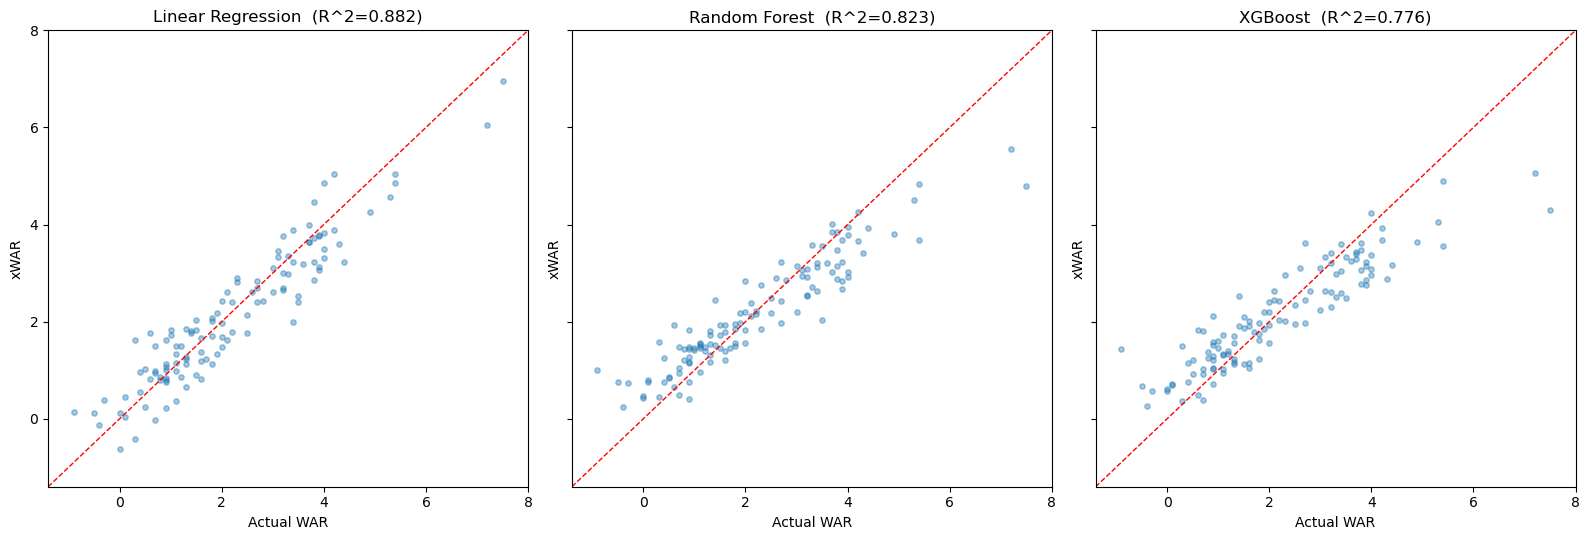

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
labels = {'lin': 'Linear Regression', 'rf': 'Random Forest', 'xgb': 'XGBoost'}

lims = [
    min(test['war'].min(), *[test[f'xWAR_{t}'].min() for t in labels]) - 0.5,
    max(test['war'].max(), *[test[f'xWAR_{t}'].max() for t in labels]) + 0.5,
]

for ax, tag in zip(axes, labels):
    ax.scatter(test['war'], test[f'xWAR_{tag}'], alpha=0.4, s=15)
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual WAR')
    ax.set_ylabel('xWAR')
    ax.set_title(f"{labels[tag]}  (R^2={r2_score(test['war'], test[f'xWAR_{tag}']):.3f})")

plt.tight_layout()
plt.show()

In [13]:
# BABIP diagnostic -- residual = actual WAR - xWAR, checked against BABIP (held aside as a
# diagnostic column in Step 3, never used as a model feature)
for tag in ['lin', 'rf', 'xgb']:
    resid = test['war'] - test[f'xWAR_{tag}']
    corr = np.corrcoef(resid, test['BABIP'])[0, 1]
    print(f'{labels[tag]:<20s} residual vs BABIP correlation: {corr:+.4f}')

Linear Regression    residual vs BABIP correlation: +0.3319
Random Forest        residual vs BABIP correlation: +0.0274
XGBoost              residual vs BABIP correlation: +0.0414


In [14]:
# Top-20 leaderboard per model, test set only
for tag in ['lin', 'rf', 'xgb']:
    print(f'\nTOP 20 -- {labels[tag]} xWAR (test set)')
    print(
        test[['Name', 'Season', 'ip', f'xWAR_{tag}', 'war']]
        .sort_values(f'xWAR_{tag}', ascending=False)
        .head(20)
        .to_string(index=False)
    )


TOP 20 -- Linear Regression xWAR (test set)
               Name  Season       ip  xWAR_lin    war
      Corbin Burnes    2021 167.0000    6.9520 7.5000
       Zack Wheeler    2021 213.1000    6.0560 7.2000
       Max Scherzer    2021 179.1000    5.0447 5.4000
         Zac Gallen    2022 184.0000    5.0348 4.2000
         Sonny Gray    2023 184.0000    4.8605 5.4000
      Logan Gilbert    2024 208.2000    4.8486 4.0000
      Kevin Gausman    2023 185.0000    4.5770 5.3000
      Corbin Burnes    2024 194.1000    4.4730 3.8000
         Logan Webb    2023 216.0000    4.2637 4.9000
      Hunter Greene    2024 150.1000    3.9877 3.7000
       Zack Wheeler    2022 153.0000    3.8949 4.2000
       Joe Musgrove    2022 181.0000    3.8915 3.4000
      Jose Quintana    2022 165.2000    3.8273 4.0000
     Freddy Peralta    2021 142.1000    3.7870 3.9000
    Clayton Kershaw    2022 126.1000    3.7653 3.9000
Lance McCullers Jr.    2021 162.1000    3.7567 3.2000
      Jesús Luzardo    2023 178.2000 

## Step 9 — Apply all three calibrated pipelines to the full dataset and export

Reuses the already-fit xRA9 models and Step 5's calibrated constants — just predicts on the full
dataset (train + test combined) so every player-season gets an xWAR from all three models.

In [15]:
full = master.copy()
full['ip_per9'] = full['ip'] / 9

# Generate xRA9 predictions for the full dataset across all models
full['xra9_lin'] = lin_ra9.predict(full[ra9_features])
full['xra9_rf']  = rf_ra9.predict(full[ra9_features])
full['xra9_xgb'] = xgb_ra9.predict(full[ra9_features])

# Compute total expected runs and calibrated xWAR
for tag in ['lin', 'rf', 'xgb']:
    full[f'xra_{tag}'] = full[f'xra9_{tag}'] * full['ip_per9']
    full[f'RAR_{tag}'], full[f'xWAR_{tag}'] = compute_xwar(full, tag)

# Label data split for reference
full['split'] = np.where(full.index.isin(test_idx), 'test', 'train')

# Export layout including fip and xra9 rates
export_cols = [
    'Name', 'Season', 'Team', 'ip', 'era', 'fip', 'war', 'split',
    'xra9_lin', 'xra9_rf', 'xra9_xgb',
    'xWAR_lin', 'xWAR_rf', 'xWAR_xgb',
]

full[export_cols].sort_values(['Season', 'xWAR_lin'], ascending=[True, False]) \
    .to_csv('xwar_pitchers_all_seasons_v2.csv', index=False)

print(f'Exported {len(full)} player-seasons to xwar_pitchers_all_seasons_v2.csv (including FIP and xRA9).')

Exported 590 player-seasons to xwar_pitchers_all_seasons_v2.csv (including FIP and xRA9).


## Notes / next steps

- **v2 feature review summary**: a p-value + VIF review (matching the process used for the hitters
  notebook) confirmed all six `ra9_features` are statistically necessary — every coefficient is
  significant at p < 0.001. No features were removed. VIF is elevated (40–105) on `gb_pct`/`fb_pct`/
  `hardhit_pct` from the expected GB%/FB%/LD% compositional relationship, but since each stayed
  significant individually, that's treated as expected structure rather than redundancy.
- **ERA as the training target is a known approximation** — it captures earned runs, not all runs
  allowed. If you can source actual runs allowed (RA) per season, retraining the RA9 models against
  true RA9 instead of ERA would remove this gap entirely.
- **Per-model calibration vs one shared calibration**: like the hitter notebook, this calibrates
  `RA9_replacement`/`RUNS_PER_WIN` separately per model. Once you settle on a final model, you can
  lock in just that one model's constants for consistency.
- **Collinearity check**: run `train[['ip_per9', 'xra_lin']].corr()` (and rf/xgb equivalents) to make
  sure the two calibration features aren't trading off against each other.
- **Starters-only scope**: this whole pipeline assumes a starter population (100+ IP). A reliever
  version would need its own dataset, its own replacement level, and likely leverage-adjusted run
  values rather than a flat RA9 conversion.
- **Plate-discipline components left out of v1/v2** (O-Swing%, Contact%, per-pitch-type breakdowns)
  are easy to re-test individually if a future version wants to probe for signal beyond what
  K%/BB%/HardHit% already capture — just watch for collinearity if added alongside the existing
  features.
- **Scoring new data**: this notebook only trains and validates against the historical dataset. To
  score any new dataset (a future season, a subset of pitchers, etc.) against the finalized linear
  model, use the companion `xWAR_test_new_data.ipynb` notebook instead of adding a cell here.